In [2]:
# ==========================================
# STEP 1 : Import Required Libraries
# ==========================================

# Import pandas for data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import KMeans clustering
from sklearn.cluster import KMeans

# Import Agglomerative Clustering (Second Algorithm)
from sklearn.cluster import AgglomerativeClustering

# Evaluation metrics
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

# Display all dataframe columns
pd.set_option("display.max_columns", None)



In [7]:
# ==========================================
# STEP 2 : Load Dataset
# ==========================================

# Read dataset
df = pd.read_csv("raw_wholesale_customers.csv")


print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

# Display first five rows
display(df.head())

Rows : 440
Columns : 8


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [8]:
# ==========================================
# STEP 3 : Inspect Dataset
# ==========================================

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print()

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())

print()

print("="*60)
print("Summary Statistics")
print("="*60)

display(df.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Missing Values
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Summary Statistics


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
# ==========================================
# STEP 4 : Select Features
# ==========================================

# Select only spending columns

features = [

    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"

]

# Create new dataframe

X = df[features].copy()

print("="*60)
print("Selected Features")
print("="*60)

display(X.head())

Selected Features


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [11]:
# ==========================================
# STEP 5 : IQR Capping
# ==========================================

for column in features:

    # Calculate first quartile
    Q1 = X[column].quantile(0.25)

    # Calculate third quartile
    Q3 = X[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Lower bound
    lower = Q1 - (1.5 * IQR)

    # Upper bound
    upper = Q3 + (1.5 * IQR)

    # Clip extreme values
    X[column] = X[column].clip(lower, upper)



In [13]:
# ==========================================
# STEP 6 : StandardScaler
# ==========================================

# Create scaler
scaler = StandardScaler()

# Scale all features
X_scaled = scaler.fit_transform(X)



print("Scaled Shape :", X_scaled.shape)

Scaled Shape : (440, 6)


In [14]:
# ==========================================
# STEP 7 : Elbow Method
# ==========================================

# Store SSE values
sse = []

# Test K values from 1 to 10
for k in range(1,11):

    model = KMeans(

        n_clusters=k,

        n_init="auto",

        random_state=42

    )

    model.fit(X_scaled)

    sse.append(model.inertia_)

    print(f"K = {k}   SSE = {model.inertia_:.2f}")

K = 1   SSE = 2640.00
K = 2   SSE = 1728.19
K = 3   SSE = 1363.45
K = 4   SSE = 1202.41
K = 5   SSE = 1070.15
K = 6   SSE = 964.76
K = 7   SSE = 921.14
K = 8   SSE = 776.63
K = 9   SSE = 726.88
K = 10   SSE = 707.41


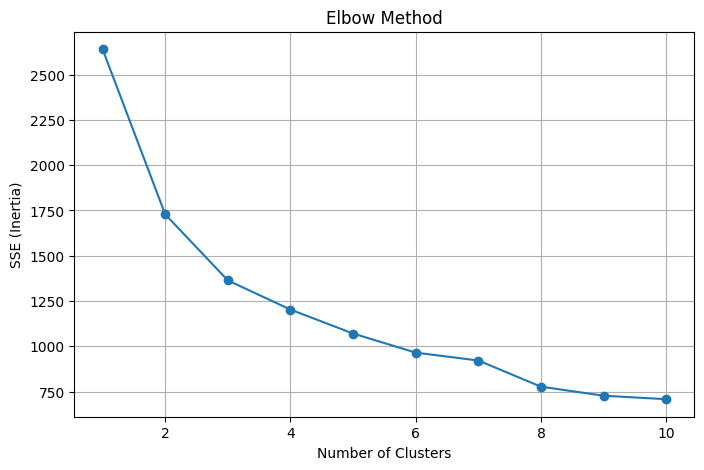

In [15]:
# ==========================================
# STEP 8 : Plot Elbow Curve
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(range(1,11), sse, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("SSE (Inertia)")

plt.grid(True)

plt.show()

In [16]:
# ==========================================
# STEP 9 : Train KMeans
# ==========================================

kmeans = KMeans(

    n_clusters=5,

    n_init="auto",

    random_state=42

)

kmeans.fit(X_scaled)

df["KMeans_Cluster"] = kmeans.labels_

print("="*60)
print("KMeans Training Completed")
print("="*60)

print(df["KMeans_Cluster"].value_counts())

KMeans Training Completed
KMeans_Cluster
1    191
3     88
0     76
4     60
2     25
Name: count, dtype: int64


In [17]:
# ==========================================
# STEP 10 : Evaluate KMeans
# ==========================================

silhouette = silhouette_score(

    X_scaled,

    kmeans.labels_

)

dbi = davies_bouldin_score(

    X_scaled,

    kmeans.labels_

)

print("="*60)
print("KMeans Evaluation")
print("="*60)

print("Silhouette Score :", silhouette)

print("Davies-Bouldin Index :", dbi)

KMeans Evaluation
Silhouette Score : 0.28305439449159625
Davies-Bouldin Index : 1.270058546306858


In [18]:
# ==========================================
# STEP 11 : Cluster Centers
# ==========================================

centers = scaler.inverse_transform(

    kmeans.cluster_centers_

)

cluster_centers = pd.DataFrame(

    centers,

    columns=features

)

print("="*60)
print("Cluster Centers")
print("="*60)

display(cluster_centers)

Cluster Centers


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9202.671053,6833.302632,9104.118421,1326.157895,3280.118421,1871.756579
1,8376.230366,2150.649215,3160.628272,1646.329843,779.251309,674.015707
2,17461.540000,13805.605000,17524.120000,4120.570000,5460.565000,3583.640000
3,22346.698864,3409.137784,3969.329545,5819.596591,583.068182,1566.946023
4,4916.983333,10768.854167,18350.133333,1212.366667,7780.018750,981.366667


In [19]:
# ==========================================
# STEP 12 : Agglomerative Clustering
# ==========================================

agglomerative = AgglomerativeClustering(

    n_clusters=5

)

df["Agglomerative_Cluster"] = agglomerative.fit_predict(

    X_scaled

)

print("="*60)
print("Agglomerative Clustering Completed")
print("="*60)

print(df["Agglomerative_Cluster"].value_counts())

Agglomerative Clustering Completed
Agglomerative_Cluster
2    164
4     79
1     72
0     70
3     55
Name: count, dtype: int64


In [20]:
# ==========================================
# STEP 13 : Compare Models
# ==========================================

kmeans_score = silhouette_score(

    X_scaled,

    df["KMeans_Cluster"]

)

agg_score = silhouette_score(

    X_scaled,

    df["Agglomerative_Cluster"]

)

print("="*60)
print("Silhouette Scores")
print("="*60)

print("KMeans :", kmeans_score)

print("Agglomerative :", agg_score)

if kmeans_score > agg_score:

    print("\nKMeans produced better separated clusters.")

else:

    print("\nAgglomerative Clustering produced better separated clusters.")

Silhouette Scores
KMeans : 0.28305439449159625
Agglomerative : 0.21848258044114816

KMeans produced better separated clusters.


In [21]:
# ==========================================
# STEP 14 : Sanity Check
# ==========================================

samples = [0, 25, 100]

columns = [

    "Channel",

    "Region",

    "Fresh",

    "Milk",

    "Grocery",

    "Frozen",

    "Detergents_Paper",

    "Delicassen",

    "KMeans_Cluster",

    "Agglomerative_Cluster"

]

print("="*60)
print("Sample Customers")
print("="*60)

display(df.loc[samples, columns])

Sample Customers


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,KMeans_Cluster,Agglomerative_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0,4
25,2,3,16165,4230,7595,201,4003,57,1,4
100,2,3,11594,7779,12144,3252,8035,3029,2,1


In [22]:
# ==========================================
# STEP 15 : Save Dataset
# ==========================================

df.to_csv(

    "segmented_wholesale_customers.csv",

    index=False

)

print("="*60)
print("Segmented Dataset Saved Successfully")
print("="*60)

Segmented Dataset Saved Successfully
